# Broken Timeline Plot Gallery

Broken timeline plots show *when* a category had meaningful activity, drawing a horizontal bar for every continuous run of data and leaving the gaps blank. They turn questions about coverage, seasonality, and operational continuity into a single glance.

Broken timeline plots excel at:
- **Data quality reads**: spot reporting gaps and ingestion outages across stores or systems
- **Operational continuity**: surface store closures, refits, and other run-time interruptions
- **Seasonal availability**: visualise when each SKU or category was actually in stock and selling
- **Threshold-driven activity**: combine `threshold_value` with `agg_func` to see when a metric cleared a meaningful bar

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import broken_timeline

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each dataset stages a real retail story (a store closed for refit,
# seasonal SKU rotation, a channel that rarely clears its activity floor)
# so the chart titles describe what the bars actually show.

# 1) Daily sales across four London stores in January 2024.
# Each store tells a different coverage story so the chart isn't just one
# anomaly against three identical bars.
#   - Camden:    full month (the baseline that reported every day)
#   - Brixton:   closed Jan 22-31 for a ten-day refurbishment
#   - Hackney:   new store, opened Jan 14 (no data before the launch date)
#   - Westfield: short POS outage Jan 10-12 (three-day blip)
_jan_2024 = pd.date_range("2024-01-01", "2024-01-31", freq="D")
_brixton_dates = _jan_2024[_jan_2024 < "2024-01-22"]
_hackney_dates = _jan_2024[_jan_2024 >= "2024-01-14"]
_westfield_dates = _jan_2024[(_jan_2024 < "2024-01-10") | (_jan_2024 > "2024-01-12")]
store_sales = pd.concat(
    [
        pd.DataFrame(
            {
                "transaction_date": _jan_2024,
                "store_id": "Camden",
                "sales_amount": 1_400,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _brixton_dates,
                "store_id": "Brixton",
                "sales_amount": 1_650,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _hackney_dates,
                "store_id": "Hackney",
                "sales_amount": 1_200,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _westfield_dates,
                "store_id": "Westfield",
                "sales_amount": 2_100,
            }
        ),
    ],
    ignore_index=True,
)

# 2) Daily sales across three product categories over Q1 2024 (12 weeks,
# Jan 1 - Mar 24). Jan 1 2024 is a Monday so the ISO weeks line up cleanly:
#   - Winter Boots: weeks 1-8 (Jan 1 - Feb 25)
#   - Spring Jackets: weeks 5-12 (Jan 29 - Mar 24); overlap with Winter Boots
#     for four weeks while the season turns over
#   - Year-Round Basics: weeks 1-12 except weeks 7-8 (Feb 12 - Feb 25), a
#     two-week supply gap from a stockout
_q1_dates = pd.date_range("2024-01-01", "2024-03-24", freq="D")
_winter_boots_dates = _q1_dates[_q1_dates <= "2024-02-25"]
_spring_jackets_dates = _q1_dates[_q1_dates >= "2024-01-29"]
_basics_dates = _q1_dates[(_q1_dates < "2024-02-12") | (_q1_dates > "2024-02-25")]
category_sales = pd.concat(
    [
        pd.DataFrame(
            {
                "transaction_date": _winter_boots_dates,
                "product_category": "Winter Boots",
                "weekly_sales": 4_200,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _spring_jackets_dates,
                "product_category": "Spring Jackets",
                "weekly_sales": 3_800,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _basics_dates,
                "product_category": "Year-Round Basics",
                "weekly_sales": 2_900,
            }
        ),
    ],
    ignore_index=True,
)

# 3) Daily revenue across three sales channels over a 21-day window in
# February 2024. Storefront and Online stay above $1K every day; Catalog
# clears the bar in two stretches with a one-week dry spell between them;
# Phone Orders only clears the bar on three scattered days.
_feb_window = pd.date_range("2024-02-01", "2024-02-21", freq="D")
_catalog_values = (
    [1_500] * 7  # Feb 1-7: above threshold
    + [400] * 7  # Feb 8-14: below threshold (dry spell)
    + [1_800] * 7  # Feb 15-21: above threshold
)
_phone_values = [400] * 21
for _phone_spike_day in (3, 11, 18):  # zero-indexed positions of three spikes
    _phone_values[_phone_spike_day] = 1_400
channel_revenue = pd.concat(
    [
        pd.DataFrame(
            {
                "transaction_date": _feb_window,
                "sales_channel": "Storefront",
                "daily_revenue": 4_500,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _feb_window,
                "sales_channel": "Online",
                "daily_revenue": 2_700,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _feb_window,
                "sales_channel": "Catalog",
                "daily_revenue": _catalog_values,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _feb_window,
                "sales_channel": "Phone Orders",
                "daily_revenue": _phone_values,
            }
        ),
    ],
    ignore_index=True,
)

# 4) Daily visitors per region across 12 weeks of 2024 (Jan 1 - Mar 24).
# North averages 470/day every week; South averages ~420/day except weeks
# 4-6 (Jan 22 - Feb 11) when a road closure dropped it to ~340/day; West
# averages ~340/day for the first 6 weeks then ~470/day after a marketing
# campaign launches in week 7 (Feb 12).
_visit_dates = pd.date_range("2024-01-01", "2024-03-24", freq="D")
_south_values = []
_west_values = []
for _d in _visit_dates:
    _week_idx = (_d - pd.Timestamp("2024-01-01")).days // 7  # 0-indexed week
    _south_values.append(340 if 3 <= _week_idx <= 5 else 420)
    _west_values.append(470 if _week_idx >= 6 else 340)
regional_visitors = pd.concat(
    [
        pd.DataFrame(
            {
                "transaction_date": _visit_dates,
                "region": "North Region",
                "daily_visitors": 470,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _visit_dates,
                "region": "South Region",
                "daily_visitors": _south_values,
            }
        ),
        pd.DataFrame(
            {
                "transaction_date": _visit_dates,
                "region": "West Region",
                "daily_visitors": _west_values,
            }
        ),
    ],
    ignore_index=True,
)

## Basic Broken Timeline

The simplest call: pass a category column and a value column, and the function draws one bar per category for every continuous run of dates with data. Reach for this when a coverage question hits the desk: *did all my stores report?*, *which days are missing from the feed?*

---

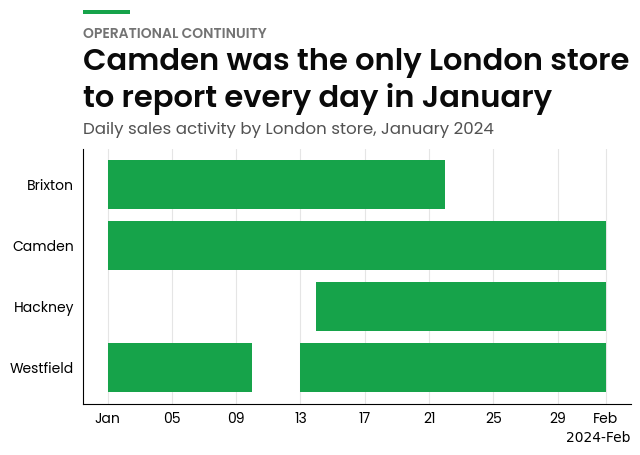

In [ ]:
ax = broken_timeline.plot(
    store_sales,
    category_col="store_id",
    value_col="sales_amount",
    eyebrow="Operational continuity",
    title="Camden was the only London store to report every day in January",
    subtitle="Daily sales activity by London store, January 2024",
)
plt.show()

## Weekly Period Aggregation

Set `period="W"` to bucket data into ISO weeks before drawing. Use weekly buckets when the natural unit of analysis is the week rather than the day, or when daily data is patchy enough that day-level gaps are noisy rather than informative. The bar widths and gap thresholds adjust to match the chosen period.

---

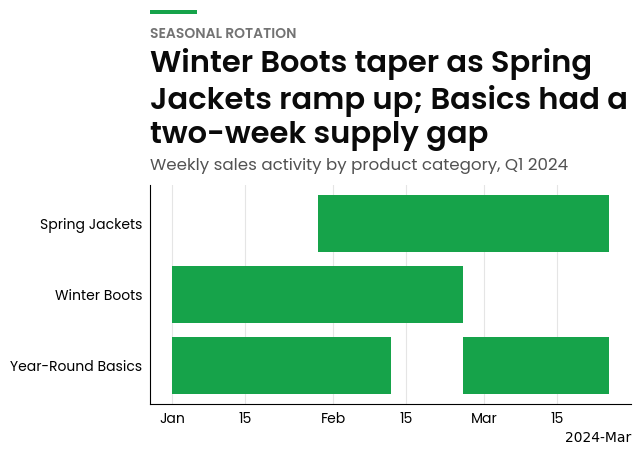

In [ ]:
ax = broken_timeline.plot(
    category_sales,
    category_col="product_category",
    value_col="weekly_sales",
    period="W",
    eyebrow="Seasonal rotation",
    title="Winter Boots taper as Spring Jackets ramp up; Basics had a two-week supply gap",
    subtitle="Weekly sales activity by product category, Q1 2024",
)
plt.show()

## Threshold Filtering

`threshold_value` drops any period whose value falls below the cutoff before the bars are drawn. Use it to focus on *meaningful* activity rather than the long tail of trickle days. The remaining bars show every period that cleared the bar, gap segments show every period that didn't.

---

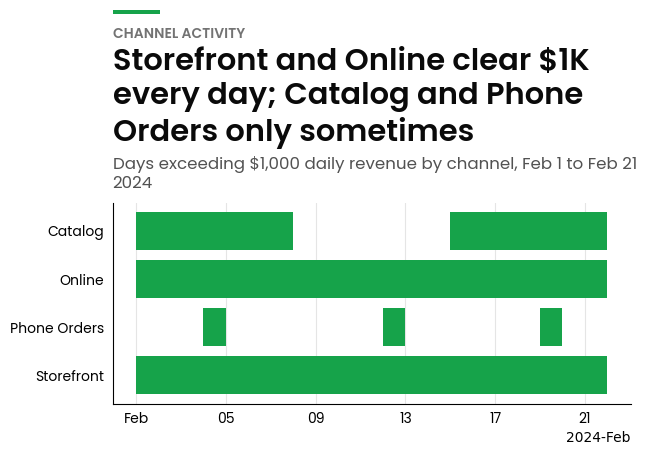

In [ ]:
ax = broken_timeline.plot(
    channel_revenue,
    category_col="sales_channel",
    value_col="daily_revenue",
    threshold_value=1_000,
    eyebrow="Channel activity",
    title="Storefront and Online clear $1K every day; Catalog and Phone Orders only sometimes",
    subtitle="Days exceeding $1,000 daily revenue by channel, Feb 1 to Feb 21 2024",
)
plt.show()

## Aggregation Function with Threshold

Pair `agg_func` with a `period` longer than a day to control what the per-period value means. Use `"mean"` to read average daily activity per week (or month) rather than the total. Combined with `threshold_value`, this surfaces the periods that sustained a target average rather than the periods that hit the target on any single day.

---

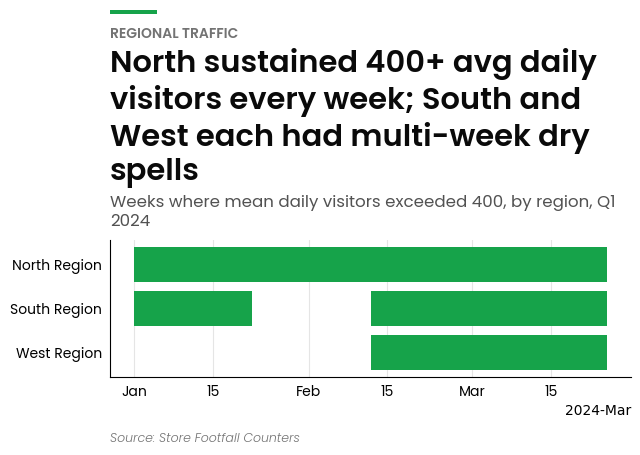

In [ ]:
ax = broken_timeline.plot(
    regional_visitors,
    category_col="region",
    value_col="daily_visitors",
    period="W",
    agg_func="mean",
    threshold_value=400,
    eyebrow="Regional traffic",
    title="North sustained 400+ avg daily visitors every week; South and West each had multi-week dry spells",
    subtitle="Weeks where mean daily visitors exceeded 400, by region, Q1 2024",
    source_text="Source: Store Footfall Counters",
)
plt.show()